We solve the one-body time-independent Schrödinger equation for the deuteron
\begin{equation}
 \left[ - \frac{\hbar^2}{2m} ∇_r^2 + V(\mathbf{r}) \right] \Psi(\mathbf{r}) = E \Psi(\mathbf{r})
\end{equation}
where

*  the reduced mass is $m = m_p m_n / (m_p + m_n)$ with $m_p = 938.27$ MeV and $m_n = 939.57$ MeV,
* the reduced Planck constant is $\hbar = 197.327$ MeV$\cdot$fm,
* relative distance $r$ is measured in fm,
* the kinetic energy term is
\begin{equation}
- \frac{\hbar^2}{2m} ∇_r^2 = - \frac{\hbar^2}{2m} \frac{1}{r^2} \frac{∂}{∂r}\left(r^2 \frac{∂}{∂r}\right) + \frac{\mathbf{L}^2}{2mr^2} \xrightarrow[\text{s-wave}]{\text{low-energy}} - \frac{\hbar^2}{2m} \frac{1}{r^2} \frac{d}{dr}\left(r^2 \frac{d}{dr}\right) = - \frac{\hbar^2}{2m} \left(\frac{2}{r}\frac{d}{dr} + \frac{d^2}{dr^2} \right)
\end{equation}
* the potential is
\begin{equation}
V(\mathbf{r})=V(r) = - g^2 e^{-\mu r/r}
\end{equation}

Let $u(\mathbf{r}) = r \Psi(\mathbf{r})$, then the Schrodinger equation becomes
\begin{equation}
- \frac{\hbar^2}{2m} \frac{d^2 u}{dr^2} + Vu = Eu.
\end{equation}

Normalization
\begin{equation}
\int \Psi^2 r^2 dr = \int u^2 dr = \frac{1}{4\pi},
\end{equation}
where $4\pi$ comes from integrating over all directions in space.

Mount to Google Drive to load ```soap``` optimizer. If it's run locally, point to the correct place for ```soap```.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/My Drive/Colab Notebooks/AI-JC_NuclearProject')

from soap import SOAP

Mounted at /content/drive


In [2]:
mp = 938.27 # MeV
mn = 939.57 # MeV
m = mp * mn / (mp + mn) # MeV
hbar = 197.327 # MeV.fm
const = hbar**2 / (2 * m) # fm^2

**Traditional numerical solver**

For potential parameters, we can choose $g = 8.23$ MeV$^{1/2}$ and $\mu=1/a$ with $a = 1.5$ fm (Compton wavelength of the pion). The energy eigenvalue is measured experimentally as $E = - 2.225$ MeV. First, let's solve using traditional solver ```solve_bvp``` from ```scipy```

In [3]:
import numpy as np
import matplotlib.pyplot as plt

g = 8.23  # MeV
a = 1.5 # fm
mu = 1.0/a
E = -2.225 # MeV

Eigenenergy E = -2.259247 MeV


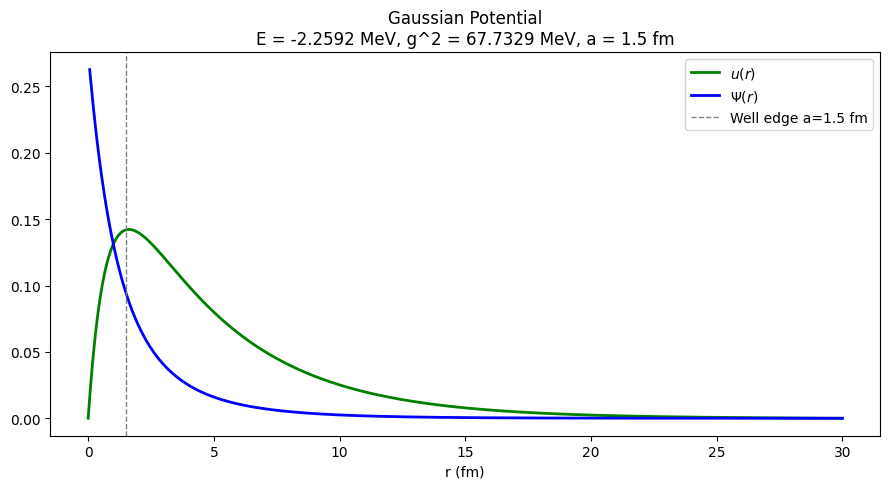

In [4]:
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

r_min = 1e-4
r_max = 30.0

# ---- Potential ----
def V(r):
    return - g**2 * np.exp(-mu * r) / r

# ---- ODE system ----
def ode(r, y, e):
    u, up = y
    d2u = (V(r) - e) * u / const
    return [up, d2u]

# ---- Shooting function ----
def shoot(e):
    sol = solve_ivp(
        lambda r, y: ode(r, y, e),
        [r_min, r_max],
        [0.0, 1.0],          # u(r_min)=0, u'(r_min)=1
        t_eval=[r_max],
        rtol=1e-6, atol=1e-8
    )
    return sol.y[0, -1]      # u(r_max)

# ---- Find eigenenergy ----
E_left = -20
E_right = -0.1

E_sol = brentq(shoot, E_left, E_right)
print(f"Eigenenergy E = {E_sol:.6f} MeV")

# ---- Solve again to get full wavefunction ----
r_eval = np.linspace(r_min, r_max, 1000)

sol = solve_ivp(
    lambda r, y: ode(r, y, E_sol),
    [r_min, r_max],
    [0.0, 1.0],
    t_eval=r_eval,
    rtol=1e-6, atol=1e-8
)

u_scipy = sol.y[0]

# ---- Normalize properly ----
norm = np.trapezoid(u_scipy**2, r_eval)
u_scipy /= np.sqrt(norm * 4 * np.pi)

psi_scipy = u_scipy / r_eval

# ---- Plot ----
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(r_eval, u_scipy, color='green', lw=2, label='$u(r)$')
ax.plot(r_eval[2:], psi_scipy[2:], color='blue', lw=2, label=r'$\Psi(r)$')
ax.axvline(x=a, color='gray', linestyle='--', lw=1,
           label=f'Well edge a={a} fm')

ax.set_xlabel('r (fm)')
#ax.set_xlim(0, 15)

plt.title(
    f'Gaussian Potential\n'
    f'E = {E_sol:.4f} MeV, g^2 = {g**2} MeV, a = {a} fm'
)

ax.legend()
plt.tight_layout()
plt.show()


**Trial 1**

Now, let's try to solve with a neural network.

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn

Sample grid points.

In [ ]:
r_min = 1e-4
r_max = 30.0 # fm, chosen to be sufficiently larger than R = 2.13 fm
'''
n_near = 4000
n_mid = 6000
n_tail = 4000

r_near = torch.linspace(r_min, R/2, n_near)
r_mid = torch.linspace(R/2, 4 * R, n_mid)
r_tail = torch.linspace(4 * R, r_max, n_tail)
r_data = torch.cat([r_near, r_mid, r_tail]).reshape(-1, 1)
'''
r_data = torch.linspace(r_min, r_max, 20000).reshape(-1, 1)

def Yukawa(r, g, mu):
    return torch.tensor(-g**2 * np.exp(-mu * r) / r)

V_data = Yukawa(r_data, g, mu)

# Data for the Schrödinger equation (points where the PDE should be satisfied)
pde_data = {'r': r_data, 'V': V_data}

# Boundary condition
r_boundary_0 = torch.tensor([[0.0]], requires_grad=True)
# For large r, the wavefunction should approach zero
r_boundary_inf = torch.tensor([[r_max]], requires_grad=True)

bc_data = { 'r_0': r_boundary_0, 'r_inf': r_boundary_inf }

/tmp/ipykernel_10971/1214140207.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return torch.tensor(-g**2 * np.exp(-mu * r) / r)
/tmp/ipykernel_10971/1214140207.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(-g**2 * np.exp(-mu * r) / r)


Define a neural network. The energy eigenvalue is a trainable parameter.

In [ ]:
class PsiNet(nn.Module):
    def __init__(self):
        super(PsiNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 64), nn.Tanh(),
            # nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )
        self.E = nn.Parameter(torch.tensor([-4.0]))

    def forward(self, r):
        # The wavefunction u(r) is approximated by the neural network
        u = self.net(r)
        return u

    def pde_loss(self, r, V, const):
        r.requires_grad_(True)
        u = self.forward(r)

        # Compute first derivative of u with respect to r
        du_dr = torch.autograd.grad(u, r,
            grad_outputs=torch.ones_like(u),
            create_graph=True,
            retain_graph=True
        )[0]

        # Compute second derivative of u with respect to r
        d2u_dr2 = torch.autograd.grad(du_dr, r,
            grad_outputs=torch.ones_like(du_dr),
            create_graph=True,
            retain_graph=True
        )[0]

        pde_residual = -const * d2u_dr2 + (V - self.E) * u
        return torch.mean(pde_residual**2)

    def boundary_loss(self, r0, r_inf):
        return (self.forward(r0)**2).mean() + (self.forward(r_inf)**2).mean()

    def norm_loss(self, r):
        u = self.forward(r)
        norm = torch.trapz(u.squeeze()**2, r.squeeze())
        return (norm - 0.25 / np.pi)**2

    def ansatz_loss(self, r):
        r.requires_grad_(True)
        u = self.forward(r)
        u_ansatz = r * torch.exp(-r / a)

        return torch.mean((u - u_ansatz)**2)

Training is carried out in two steps:


1.   The network is trained to an ansatz that approximates the solution, $u_{ans}(r) = r e^{-r/R}$,
2.   The network is relaxed to the PDE solution contrained by the norm and boundary conditions.



In [ ]:
# Initialize the model
model = PsiNet()
print("PsiNet model initialized.")
print(model)

epochs1 = 600
epochs2 = 2000

# optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = SOAP(params=model.parameters(), lr = 1e-3, betas=(.95, .95), weight_decay=.01, precondition_frequency=10)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.5)
for epoch in range(epochs1):
    optimizer.zero_grad()

    # Fresh graph node each epoch
    r_pde = r_data.clone()
    V_pde = V_data.clone()

    # Ansatz loss
    loss = model.ansatz_loss(r_pde)

    # Back propagation
    loss.backward()
    optimizer.step()
    scheduler.step()

    if (epoch + 1) % 200 == 0:
        print(f'Epoch {epoch+1}/{epochs1} '
              f'Ansatz Loss: {loss.item():.6f}')

print("Training ansatz finished.")

# optimizer = optim.Adam(model.parameters(), lr=0.0001)
optimizer = SOAP(params=model.parameters(), lr = 1e-4, betas=(.95, .95), weight_decay=.01, precondition_frequency=10)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.5)

# for plotting
pde_losses = []
bc_losses = []
norm_losses = []
total_losses = []

for epoch in range(epochs2):
    optimizer.zero_grad()

    # Fresh graph node each epoch
    r_pde = r_data.clone()
    V_pde = V_data.clone()

    # PDE Loss
    pde_loss = model.pde_loss(r_pde, V_pde, const)
    pde_losses.append(pde_loss.item())

    # BC Loss at r=0
    r_boundary_0 = torch.tensor([[r_min]])
    r_boundary_inf = torch.tensor([[r_max]])
    bc_loss = model.boundary_loss(r_boundary_0, r_boundary_inf)
    bc_losses.append(bc_loss.item())

    # Norm loss
    norm_loss = model.norm_loss(r_pde)
    norm_losses.append(norm_loss.item())

    # Total Loss
    total_loss = 10*pde_loss + 1000*bc_loss + 50*norm_loss
    total_losses.append(total_loss.item())

    total_loss.backward()
    optimizer.step()
    scheduler.step()

    # Early stopping
    if epoch > 1000 and abs(np.mean(pde_losses[-100:]) < pde_loss.item()) < 1e-10:
        break

    if (epoch + 1) % 200 == 0:
        print(f'Epoch {epoch+1}/{epochs2} '
              f'Total Loss: {total_loss.item():.6f} '
              f'PDE Loss: {pde_loss.item():.6f} '
              f'BC0 Loss: {bc_loss.item():.6f} '
              f'Norm Loss: {norm_loss.item():.6f}')

print("Training to PDE finished.")

PsiNet model initialized.
PsiNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): Tanh()
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Epoch 200/600 Ansatz Loss: 0.000050
Epoch 400/600 Ansatz Loss: 0.000000
Epoch 600/600 Ansatz Loss: 0.000000
Training ansatz finished.
Epoch 200/2000 Total Loss: 8.734898 PDE Loss: 0.464254 BC0 Loss: 0.000000 Norm Loss: 0.081847
Epoch 400/2000 Total Loss: 3.858752 PDE Loss: 0.198680 BC0 Loss: 0.000000 Norm Loss: 0.037435
Epoch 600/2000 Total Loss: 1.488313 PDE Loss: 0.089473 BC0 Loss: 0.000000 Norm Loss: 0.011870
Epoch 800/2000 Total Loss: 0.406373 PDE Loss: 0.033668 BC0 Loss: 0.000000 Norm Loss: 0.001392
Epoch 1000/2000 Total Loss: 0.114078 PDE Loss: 0.010867 BC0 Loss: 0

Plot the results.

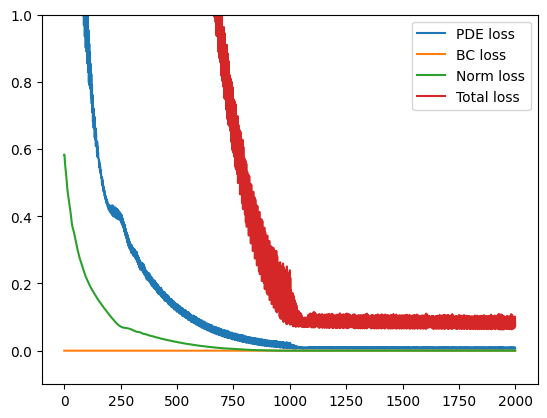

In [ ]:
# Plotting losses
plt.plot(pde_losses, label="PDE loss")
plt.plot(bc_losses, label="BC loss")
plt.plot(norm_losses,label="Norm loss")
plt.plot(total_losses, label="Total loss")
plt.ylim(-0.1,1)
plt.legend()
plt.show()

Eigenenergy E = -3.844316 MeV


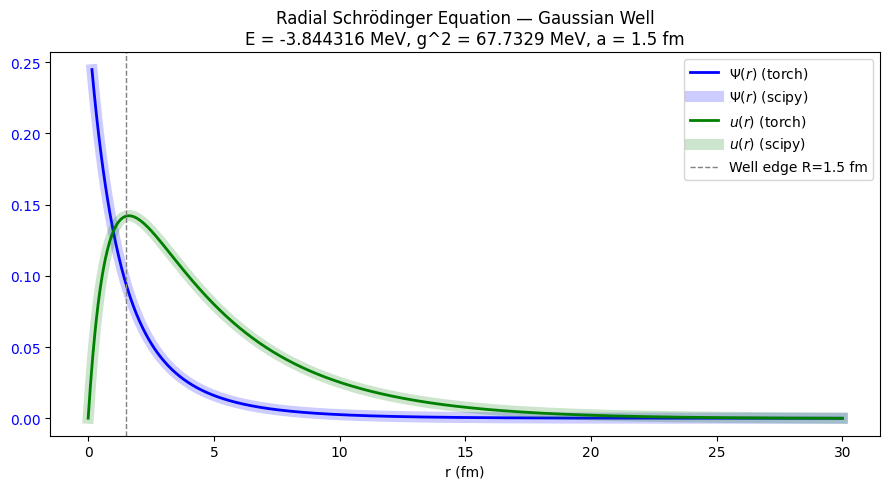

In [ ]:
# Print out E
print(f"Eigenenergy E = {model.E.item():.6f} MeV")

# Generate r values for plotting
r_plot = torch.linspace(r_min, r_max, 1000).reshape(-1, 1)

# Get predicted Psi(r) from the trained model
model.eval() # Set model to evaluation mode
with torch.no_grad():
    u_nn = model(r_plot)

norm = torch.trapz(u_nn.squeeze()**2, r_plot.squeeze())
u_nn = u_nn / torch.sqrt(norm * 4 * torch.pi)
psi_nn = u_nn / r_plot

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(r_plot[5:], psi_nn[5:], color='blue', lw=2, label=r'$\Psi(r)$ (torch)')
ax.plot(r_plot[5:], psi_scipy[5:], color='blue', lw=8, label=r'$\Psi(r)$ (scipy)', alpha=0.2)

ax.plot(r_plot, u_nn, color='green', lw=2, label=r'$u(r)$ (torch)')
ax.plot(r_plot, u_scipy, color='green', lw=8, label=r'$u(r)$ (scipy)', alpha=0.2)

ax.axvline(x=a, color='gray', linestyle='--', lw=1, label=f'Well edge R={a} fm')
ax.set_xlabel('r (fm)')
# ax.set_ylabel('Ψ(r)', color='blue')
ax.tick_params(axis='y', labelcolor='blue')

plt.title(f'Radial Schrödinger Equation — Yukawa potential\nE = {model.E.item():.6f} MeV, g^2 = {g**2} MeV, a = {a} fm')
plt.legend()
plt.tight_layout()
plt.show()

**Trial 2**

Adaptation from Xiaoliang's work with PINN-Rayleigh Loss:
\begin{equation}
\mathcal{L} = \lambda_R \mathcal{E}_\theta+\lambda_{\mathrm{pde}}\langle|-K u_\theta''+Vu_\theta-E_\theta u_\theta|^2\rangle+\lambda_{\mathrm{match}}(E_\theta-\mathcal{E}_\theta)^2+\lambda_{\mathrm{norm}}(\int u_\theta^2dr-1/4\pi)^2+\lambda_Du_\theta(r_{\max})^2,
\end{equation}
where $K = \hbar^2/2m$, $E_\theta$ is trainable and
$$\mathcal{E}_\theta=\frac{\int_0^{r_{\max}} K|u_\theta'|^2+V|u_\theta|^2\,dr}{\int_0^{r_{\max}} |u_\theta|^2\,dr}$$
is the Rayleigh quotient. The $\lambda$'s weight the importance of each loss term.  Interpretation of each term in the loss is as follows

- 1st term: Rayleigh energy
- 2nd term: PINN loss
- 3rd term: matching the trainable energy to the Rayley energy
- 4th term: normalize the radial wave function
- 5th term: boundary condition at infinity

First, create training data. The PDE residual samples use a mixture distribution: uniform samples on the full interval, extra samples near the origin, and extra samples near the square-well discontinuity. The Rayleigh and normalization integrals use independent uniform random samples over the full interval and are resampled at every training step.

In [5]:
from dataclasses import dataclass
import random
import torch
import torch.nn as nn

In [12]:
r_min = 1e-4
r_max = 30.0

# Fix seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Define potential
def potential_torch(r):
    return -g**2 * torch.exp(-mu * r) / r

# Define configuration parameters for training
@dataclass
class TrainConfig:
    n_interior: int = 3000
    n_origin: int = 3000
    n_rayleigh: int = 3000
    origin_width: float = 0.6
    lambda_rayleigh: float = 1.0
    lambda_norm: float = 10.0
    lambda_boundary: float = 10.0
    lambda_pde_cap: float = 0.8
    lambda_match_cap: float = 0.5
    warmup_steps: int = 2000
    ramp_steps: int = 3000
    grad_balance_every: int = 25
    grad_balance_ema: float = 0.5
    grad_balance_pde_scale: float = 0.5
    grad_balance_match_scale: float = 0.5
    grad_balance_min: float = 1e-4
    grad_balance_eps: float = 1e-12

cfg = TrainConfig()

def sample_pde_points(cfg, device, dtype):
    # Sample the full interval
    pts = [torch.rand(cfg.n_interior, 1, device=device, dtype=dtype) * r_max + r_min]

    # Sample near the origin
    pts.append(torch.rand(cfg.n_origin, 1, device=device, dtype=dtype) * cfg.origin_width + r_min)

    # Assemble
    r = torch.cat(pts, dim=0)
    r.requires_grad_(True)
    return r

def sample_uniform_rayleigh(n, device, dtype):
    r = torch.rand(n, 1, device=device, dtype=dtype) * r_max + r_min
    r.requires_grad_(True)
    return r, r_max / n # the 2nd output approximates the interval size

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
print(f'Using device: {device}')
print(f'PDE samples per step: {cfg.n_interior + cfg.n_origin}')
print(f'Rayleigh samples per step: {cfg.n_rayleigh}')

Using device: cpu
PDE samples per step: 6000
Rayleigh samples per step: 3000


Next, we define a neural network $N_\theta(r)$ that approximates the radial wave function via an ansatz
$$
u_\theta(r) = r e^{-\alpha r} N_{\theta}(r) \text{ with } \alpha = 0.25 \text{ fm}^{-1}.
$$
The network input is rescaled from $[0,r_{\max}]$ to $[-1,1]$.

In [13]:
class RadialNet(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=3, alpha=0.25, energy_init=-3.0):
        # Define layers
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

        self.register_buffer('alpha', torch.tensor(float(alpha)))
        self.energy = nn.Parameter(torch.tensor([energy_init], dtype=torch.float32))

    # Forward pass
    def forward(self, r):
        # r is expected to be of shape (N, 1)
        x = 2.0 * r / r_max - 1.0 # mapping to [-1,1]
        return r * torch.exp(-self.alpha * r) * self.net(x)

    # Loss
    def loss(self, cfg, device, dtype, lambda_pde, lambda_match): # the last two are adjusted during training
        # Norm
        r_R, w = sample_uniform_rayleigh(cfg.n_rayleigh, device, dtype)
        u_R = self(r_R)
        norm = w * torch.sum(u_R.squeeze() ** 2)
        norm_loss = (norm - 0.25/np.pi) ** 2

        # Rayleigh
        du_R = torch.autograd.grad(u_R, r_R,
                                   grad_outputs=torch.ones_like(u_R),
                                   create_graph=True, retain_graph=True)[0]

        kinetic_R = w * torch.sum(const * du_R.squeeze() ** 2)
        V_R = potential_torch(r_R)
        potential_R = w * torch.sum(V_R.squeeze() * u_R.squeeze() ** 2)
        Rayleigh_loss = (kinetic_R + potential_R) / torch.clamp(norm, min=1e-12)

        # Boundary
        r_boundary = torch.tensor([[r_max]], device=device, dtype=dtype, requires_grad=True)
        boundary_loss = self.net(r_boundary).squeeze() ** 2

        # PDE
        r_pde = sample_pde_points(cfg, device, dtype)
        u_pde = self(r_pde)
        du_pde = torch.autograd.grad(u_pde, r_pde,
                                     grad_outputs=torch.ones_like(u_pde),
                                     create_graph=True, retain_graph=True)[0]
        d2u_pde = torch.autograd.grad(du_pde, r_pde,
                                      grad_outputs=torch.ones_like(du_pde),
                                      create_graph=True, retain_graph=True)[0]
        residual = -const * d2u_pde + potential_torch(r_pde) * u_pde - self.energy * u_pde
        pde_loss = torch.mean(residual ** 2)

        # Match
        match_loss = (self.energy - Rayleigh_loss) ** 2

        # Assemble
        loss = cfg.lambda_rayleigh * Rayleigh_loss + \
               lambda_pde * pde_loss + \
               lambda_match * match_loss + \
               cfg.lambda_norm * norm_loss + \
               cfg.lambda_boundary * boundary_loss

        terms = {
          'rayleigh_energy': Rayleigh_loss,
          'pde_loss': pde_loss,
          'match_loss': match_loss,
          'norm_loss': norm_loss,
          'boundary_loss': boundary_loss,
        }

        return loss, terms

Next, define reusable utilities. Validation is performed on a fixed dense grid, independent of the random training samples. The model solution is normalized and sign-aligned with the exact solution before computing the $L^2$ error.

In [14]:
def validate_model(r_eval, model):
    model.eval()
    # Ensure r has shape (num_samples, 1) for consistency with the network's expected input
    r = torch.tensor(r_eval, device=device, dtype=dtype, requires_grad=True).reshape(-1, 1)

    u = model(r)
    du = torch.autograd.grad(u, r, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    d2u = torch.autograd.grad(du, r, grad_outputs=torch.ones_like(du), create_graph=False)[0]

    v = potential_torch(r)
    rf = r.squeeze()
    uf = u.squeeze()
    duf = du.squeeze()

    norm = torch.trapezoid(uf ** 2, rf)
    norm_loss = (norm - 0.25/np.pi) ** 2

    kinetic = torch.trapezoid(const * duf ** 2, rf)
    potential = torch.trapezoid(v.squeeze() * uf ** 2, rf)
    rayleigh_energy = (kinetic + potential) / norm

    residual = -const * d2u.squeeze() + v.squeeze() * uf - model.energy.item() * uf
    pde_loss = torch.mean(residual ** 2)

    u_np = uf.detach().cpu().numpy()
    r_np = rf.detach().cpu().numpy()
    u_norm = u_np / np.sqrt(norm.item() * 4 * np.pi)

    if (u_norm[10] * u_scipy[10]) < 0:
        u_norm = -u_norm
    l2 = np.sqrt(np.trapezoid((u_norm - u_scipy) ** 2, r_np))

    metrics = {
        'rayleigh_energy': rayleigh_energy.item(),
        'norm_loss': norm_loss.item(),
        'pde_loss': pde_loss.item(),
        'u_rmax': uf[-1].item(),
        'l2': l2,
        'learned_energy': model.energy.item(),
        'energy_error': abs(model.energy.item() - E_sol),
    }
    return metrics, r_np, u_norm

def print_metrics(metrics):
    for key, value in metrics.items():
        if key == 'label':
            print(value)
        elif isinstance(value, float):
            print(f'  {key}: {value:.8g}')

def plot_solution(model, r, u_nn):
    fig, ax = plt.subplots(figsize=(9, 5))
    psi_nn = u_nn / r

    ax.plot(r, psi_nn, color='blue', lw=2, label=r'$\Psi(r)$ (torch)')
    ax.plot(r[5:], psi_scipy[5:], color='blue', lw=8, label=r'$\Psi(r)$ (scipy)', alpha=0.2)

    ax.plot(r, u_nn, color='green', lw=2, label=r'$u(r)$ (torch)')
    ax.plot(r, u_scipy, color='green', lw=8, label=r'$u(r)$ (scipy)', alpha=0.2)

    ax.axvline(x=a, color='gray', linestyle='--', lw=1, label=f'Well edge a={a} fm')
    ax.set_xlabel('r (fm)')
    # ax.set_ylabel('Ψ(r)', color='blue')
    ax.tick_params(axis='y', labelcolor='blue')

    plt.title(f'Radial Schrödinger Equation — Yukawa potential\nE = {model.energy.item():.6f} MeV, g^2 = {g**2} MeV, a = {a} fm')
    plt.legend()
    plt.tight_layout()
    plt.show()

Before training, note that the PINN-Rayleigh loss can be difficult to weight manually because the Rayleigh term is an energy, while the PDE term is a squared residual. Here the Rayleigh term is treated as the anchor. During training, the PDE and energy-matching weights are adjusted from gradient norms:

$$\lambda_i(t)\approx c_i\frac{\|\nabla_\theta\mathcal{E}_\theta\|}{\|\nabla_\theta\mathcal{L}_i\|+\epsilon},$$

where $\mathcal{L}_i$ is either the PDE residual loss or the energy-matching loss. We also use a Rayleigh warmup: for the first 2000 steps the PDE and matching weights are zero, then their maximum allowed values ramp over 3000 steps to $\lambda_{\mathrm{pde}}\le0.1$ and $\lambda_{\mathrm{match}}\le0.5$. This lets the variational objective find the correct bound-state basin before the local PDE residual becomes active.

In [15]:
def grad_norm(term, parameters):
    if not term.requires_grad:
        return 0.0
    grads = torch.autograd.grad(term, parameters, retain_graph=True,
                                create_graph=False, allow_unused=True)
    total = torch.zeros((), device=term.device, dtype=term.dtype)
    for g in grads:
        if g is not None:
            total = total + g.detach().pow(2).sum()
    return float(torch.sqrt(total).cpu())

def schedule_caps(step, cfg):
    if step <= cfg.warmup_steps:
        progress = 0.0
    else:
        progress = min(1.0, (step - cfg.warmup_steps) / max(1, cfg.ramp_steps))
    return progress * cfg.lambda_pde_cap, progress * cfg.lambda_match_cap

def balanced_weight(anchor_norm, term_norm, cap, scale, cfg):
    if cap <= 0.0 or anchor_norm <= cfg.grad_balance_eps or term_norm <= cfg.grad_balance_eps:
        return 0.0
    raw = scale * anchor_norm / (term_norm + cfg.grad_balance_eps)
    return min(cap, max(min(cfg.grad_balance_min, cap), raw))

def train_pinn_rayleigh_grad_balance(steps=10000, lr=3e-3, seed=42):
    set_seed(seed)

    # Initialize the network
    model = RadialNet().to(device=device, dtype=dtype)

    # Call optimizer
    opt = SOAP(model.parameters(), lr=lr, betas=(0.95, 0.95), weight_decay=0.0, precondition_frequency=10)

    params = [p for p in model.parameters() if p.requires_grad]
    lambda_pde = 0.0
    lambda_match = 0.0
    total_losses = []
    history = []

    for step in range(1, steps + 1):
        pde_cap, match_cap = schedule_caps(step, cfg)
        loss, terms = model.loss(cfg, device, dtype, pde_cap, match_cap)
        total_losses.append(loss.item())

        # Produce new lambda_pde and lambda_match
        if step == 1 or step % cfg.grad_balance_every == 0:
            g_ray = grad_norm(terms['rayleigh_energy'], params)
            g_pde = grad_norm(terms['pde_loss'], params)
            g_match = grad_norm(terms['match_loss'], params)
            next_pde = balanced_weight(g_ray, g_pde, pde_cap, cfg.grad_balance_pde_scale, cfg)
            next_match = balanced_weight(g_ray, g_match, match_cap, cfg.grad_balance_match_scale, cfg)
            ema = cfg.grad_balance_ema
            lambda_pde = next_pde if step == 1 else ema * lambda_pde + (1.0 - ema) * next_pde
            lambda_match = next_match if step == 1 else ema * lambda_match + (1.0 - ema) * next_match

        lambda_pde = min(pde_cap, max(0.0, lambda_pde))
        lambda_match = min(match_cap, max(0.0, lambda_match))

        # Back propagation
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        # Print occasionally
        if step == 1 or step % 500 == 0 or step == steps:
            row = {
                'step': step,
                'loss': loss.item(),
                'rayleigh': terms['rayleigh_energy'].item(),
                'pde_loss': terms['pde_loss'].item(),
                'match_loss': terms['match_loss'].item(),
                'norm_loss': terms['norm_loss'].item(),
                'boundary_loss': terms['boundary_loss'].item(),
                'E_theta': model.energy.item(), # Fixed: Changed model.energy() to model.energy.item()
                'lambda_pde': lambda_pde,
                'lambda_match': lambda_match,
            }
            history.append(row)
            print(row)

        # Early stopping
        if step > 3000 and abs(np.mean(total_losses[-200:]) < loss.item()) < 1e-10:
            break

    return model, history

We are ready to train.

In [16]:
pinn_model, pinn_history = train_pinn_rayleigh_grad_balance(steps=10000)

{'step': 1, 'loss': -0.5626093149185181, 'rayleigh': -0.6415120959281921, 'pde_loss': 5.1804890632629395, 'match_loss': 5.562464714050293, 'norm_loss': 0.0015052452217787504, 'boundary_loss': 0.006385035812854767, 'E_theta': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 500, 'loss': -0.3949902057647705, 'rayleigh': -0.4096500873565674, 'pde_loss': 0.9056679010391235, 'match_loss': 6.7099127769470215, 'norm_loss': 0.0013969080755487084, 'boundary_loss': 6.907767237862572e-05, 'E_theta': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1000, 'loss': -1.6271854639053345, 'rayleigh': -1.635033369064331, 'pde_loss': 1.49567711353302, 'match_loss': 1.8631339073181152, 'norm_loss': 0.0003271843015681952, 'boundary_loss': 0.00045760630746372044, 'E_theta': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1500, 'loss': -0.10033988952636719, 'rayleigh': -0.10198470950126648, 'pde_loss': 1.592664361000061, 'match_loss': 8.398492813110352, 'norm_loss': 0.00013062419020570815, 

  rayleigh_energy: -2.2473793
  norm_loss: 0.00060268026
  pde_loss: 0.0013890314
  u_rmax: 1.1354368e-05
  l2: 0.0089592911
  learned_energy: -2.2472506
  energy_error: 0.011996605


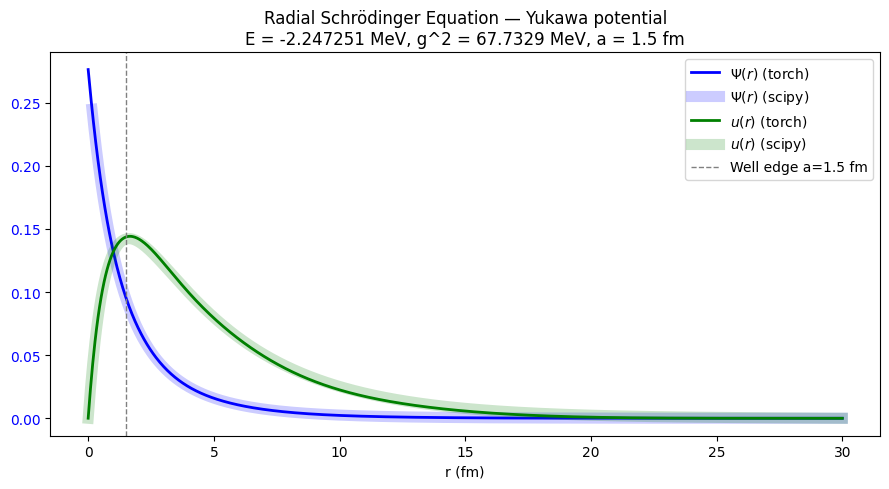

In [17]:
pinn_metrics, r_plot, u_pinn = validate_model(r_eval, pinn_model)
print_metrics(pinn_metrics)
plot_solution(pinn_model, r_plot, u_pinn)